In [ ]:
# Google Play Store Data Analysis

This project analyzes Google Play Store data using Python, Pandas and Plotly.

In [ ]:
## Question 1

Use a grouped bar chart to compare the average rating and total review count for the top 10 app categories by number of installs. Filter out any categories where the average rating is below 4.0, size below 10 MB, and last update should be in January. This graph should work only between 3 PM IST to 5 PM IST.

In [1]:
import pandas as pd
import plotly.graph_objects as go
from zoneinfo import ZoneInfo

df = pd.read_csv(r"C:\Users\payal\Downloads\apps.csv.zip")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Size_M"] = df["Size"].astype(str).str.replace("M", "")
df["Size_M"] = pd.to_numeric(df["Size_M"], errors="coerce")

df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

df = df[
    (df["Rating"] >= 4.0) &
    (df["Size_M"] >= 10) &
    (df["Last Updated"].dt.month == 1)
]

result = df.groupby("Category").agg(
    Average_Rating=("Rating", "mean"),
    Total_Reviews=("Reviews", "sum"),
    Total_Installs=("Installs", "sum")
).reset_index()

result = result.sort_values("Total_Installs", ascending=False).head(10)

current_time = pd.Timestamp.now(tz=ZoneInfo("Asia/Kolkata"))
minutes = current_time.hour * 60 + current_time.minute

if 15 * 60 <= minutes < 17 * 60:
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=result["Category"],
        y=result["Average_Rating"],
        name="Average Rating"
    ))

    fig.add_trace(go.Bar(
        x=result["Category"],
        y=result["Total_Reviews"],
        name="Total Reviews",
        yaxis="y2"
    ))

    fig.update_layout(
        title="Average Rating and Total Reviews of Top 10 Categories",
        xaxis_title="App Category",
        yaxis_title="Average Rating",
        yaxis2=dict(
            title="Total Reviews",
            overlaying="y",
            side="right"
        ),
        barmode="group"
    )

    fig.show()

else:
    print("Current IST Time:", current_time.strftime("%I:%M %p"))
    print("Graph is hidden. It will be shown only between 3 PM and 5 PM IST.")

Current IST Time: 01:02 PM
Graph is hidden. It will be shown only between 3 PM and 5 PM IST.


In [ ]:
## Question 2

Create an interactive Choropleth map using Plotly to visualize global installs by Category. Apply filters to show data for only the top 5 app categories and highlight categories where the number of installs exceeds 1 million. The app category should not start with the characters "A", "C", "G", or "S". This graph should work only between 6 PM IST and 8 PM IST.

In [2]:
import pandas as pd
import plotly.express as px
from zoneinfo import ZoneInfo

df = pd.read_csv(r"C:\Users\payal\Downloads\apps.csv.zip")

df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

if "Country" not in df.columns:
    print("Country column is not present in this dataset.")
    print("Choropleth map needs country-wise data.")

else:
    df = df[
        ~df["Category"].str.startswith(("A", "C", "G", "S"), na=False)
    ]

    df = df.dropna(subset=["Country", "Category", "Installs"])

    top5 = (
        df.groupby("Category")["Installs"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    df = df[df["Category"].isin(top5.index)]

    result = df.groupby(
        ["Country", "Category"]
    )["Installs"].sum().reset_index()

    result["Highlight"] = result["Installs"] > 1000000

    current_time = pd.Timestamp.now(tz=ZoneInfo("Asia/Kolkata"))
    minutes = current_time.hour * 60 + current_time.minute

    if 18 * 60 <= minutes < 20 * 60:

        fig = px.choropleth(
            result,
            locations="Country",
            locationmode="country names",
            color="Installs",
            hover_name="Country",
            hover_data=["Category", "Highlight"],
            title="Global Installs by Top 5 App Categories"
        )

        fig.show()

    else:
        print("Current IST Time:", current_time.strftime("%I:%M %p"))
        print("Graph is hidden. It will be shown only between 6 PM and 8 PM IST.")

Country column is not present in this dataset.
Choropleth map needs country-wise data.


In [ ]:
## Question 3

Create a dual-axis chart comparing the average installs and revenue for free vs. paid apps within the top 3 app categories. Apply filters to exclude apps with fewer than 10,000 installs and revenue below $10,000, Android version should be more than 4.0, size should be more than 15 MB, content rating should be Everyone, and app name should not have more than 30 characters including spaces and special characters. This graph should work only between 1 PM IST to 2 PM IST.

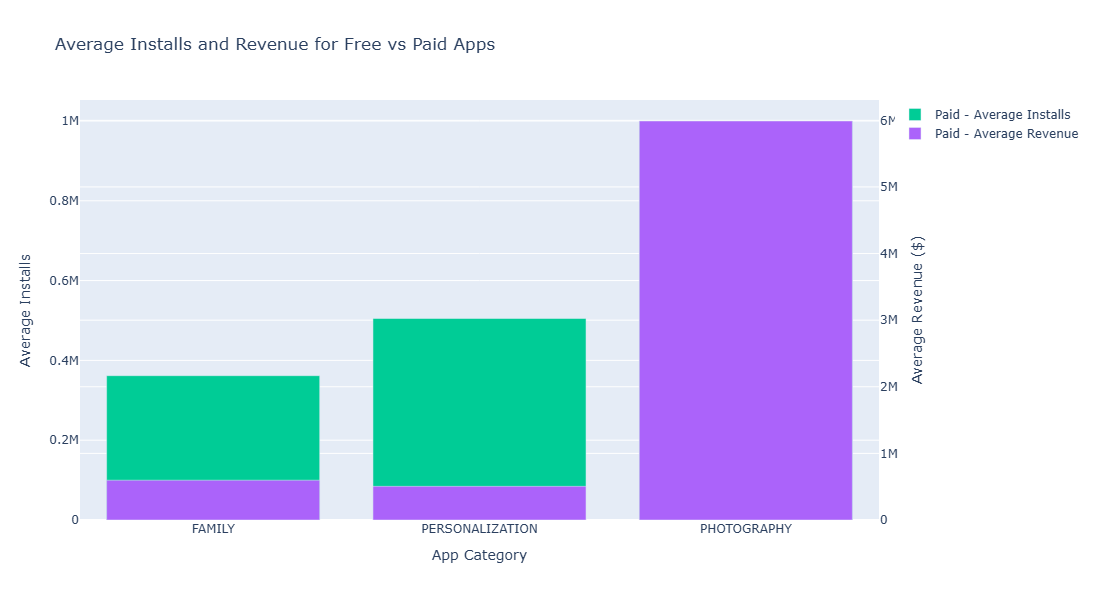

In [3]:
import pandas as pd
import plotly.graph_objects as go
from zoneinfo import ZoneInfo

df = pd.read_csv(r"C:\Users\payal\Downloads\apps.csv.zip")

df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Size_M"] = df["Size"].astype(str).str.replace("M", "")
df["Size_M"] = pd.to_numeric(df["Size_M"], errors="coerce")

df["Android_Version"] = pd.to_numeric(
    df["Android Ver"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)

df["App_Length"] = df["App"].astype(str).str.len()

df["Revenue"] = df["Installs"] * df["Price"]

df = df[
    (df["Installs"] >= 10000) &
    (df["Revenue"] >= 10000) &
    (df["Android_Version"] > 4.0) &
    (df["Size_M"] > 15) &
    (df["Content Rating"] == "Everyone") &
    (df["App_Length"] <= 30)
]

top3 = (
    df.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

df = df[df["Category"].isin(top3)]

result = df.groupby(["Category", "Type"]).agg(
    Average_Installs=("Installs", "mean"),
    Average_Revenue=("Revenue", "mean")
).reset_index()

current_time = pd.Timestamp.now(tz=ZoneInfo("Asia/Kolkata"))
minutes = current_time.hour * 60 + current_time.minute

if 13 * 60 <= minutes < 14 * 60:

    fig = go.Figure()

    for app_type in ["Free", "Paid"]:

        temp = result[result["Type"] == app_type]

        fig.add_trace(go.Bar(
            x=temp["Category"],
            y=temp["Average_Installs"],
            name=app_type + " - Average Installs"
        ))

        fig.add_trace(go.Bar(
            x=temp["Category"],
            y=temp["Average_Revenue"],
            name=app_type + " - Average Revenue",
            yaxis="y2"
        ))

    fig.update_layout(
        title="Average Installs and Revenue for Free vs Paid Apps",
        xaxis_title="App Category",
        yaxis=dict(title="Average Installs"),
        yaxis2=dict(
            title="Average Revenue ($)",
            overlaying="y",
            side="right"
        ),
        barmode="group",
        height=600
    )

    fig.show()

else:
    print("Current IST Time:", current_time.strftime("%I:%M %p"))
    print("Graph is hidden. It will be shown only between 1 PM and 2 PM IST.")

In [ ]:
## Question 4

Plot a time series line chart to show the trend of total installs over time, segmented by app category. Highlight periods of significant growth by shading the areas under the curve where the increase in installs exceeds 20% month-over-month. App names should not start with X, Y or Z, app category should start with E, C or B, Beauty should be translated into Hindi, Business into Tamil, and Dating into German. Reviews should be more than 500 and app names should not contain the letter S. This graph should work only between 6 PM IST to 9 PM IST.

In [4]:
import pandas as pd
import plotly.graph_objects as go
from zoneinfo import ZoneInfo

df = pd.read_csv(r"C:\Users\payal\Downloads\apps.csv.zip")

df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Last Updated"] = pd.to_datetime(
    df["Last Updated"], errors="coerce"
)

df = df[
    (~df["App"].astype(str).str.lower().str.startswith(("x", "y", "z"))) &
    (~df["App"].astype(str).str.contains("s", case=False, na=False)) &
    (df["Category"].astype(str).str.startswith(("E", "C", "B"), na=False)) &
    (df["Reviews"] > 500)
]

df["Month"] = df["Last Updated"].dt.to_period("M").astype(str)

result = df.groupby(
    ["Month", "Category"]
)["Installs"].sum().reset_index()

translation = {
    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Dating"
}

result["Display_Category"] = (
    result["Category"].str.upper().map(translation)
    .fillna(result["Category"])
)

current_time = pd.Timestamp.now(tz=ZoneInfo("Asia/Kolkata"))
minutes = current_time.hour * 60 + current_time.minute

if 18 * 60 <= minutes < 21 * 60:

    fig = go.Figure()

    for category in result["Category"].unique():

        temp = result[
            result["Category"] == category
        ].copy()

        temp = temp.sort_values("Month")

        temp["Growth"] = temp["Installs"].pct_change() * 100

        name = temp["Display_Category"].iloc[0]

        fig.add_trace(go.Scatter(
            x=temp["Month"],
            y=temp["Installs"],
            mode="lines+markers",
            name=name
        ))

        for i in range(1, len(temp)):

            if temp["Growth"].iloc[i] > 20:

                fig.add_trace(go.Scatter(
                    x=[
                        temp["Month"].iloc[i - 1],
                        temp["Month"].iloc[i],
                        temp["Month"].iloc[i]
                    ],
                    y=[
                        temp["Installs"].iloc[i - 1],
                        temp["Installs"].iloc[i],
                        0
                    ],
                    fill="toself",
                    mode="none",
                    fillcolor="rgba(255,165,0,0.25)",
                    showlegend=False
                ))

    fig.update_layout(
        title="Trend of Total Installs Over Time",
        xaxis_title="Month",
        yaxis_title="Total Installs",
        hovermode="x unified",
        height=600
    )

    fig.show()

else:

    print(
        "Current IST Time:",
        current_time.strftime("%I:%M %p")
    )

    print(
        "Graph is hidden. It will be shown only between 6 PM and 9 PM IST."
    )

Current IST Time: 01:04 PM
Graph is hidden. It will be shown only between 6 PM and 9 PM IST.


In [ ]:
## Question 5

Plot a bubble chart to analyze the relationship between app size (in MB) and average rating, with the bubble size representing the number of installs. Include only apps with a rating higher than 3.5 from the Game, Beauty, Business, Comics, Communication, Dating, Entertainment, Social and Events categories. Reviews should be greater than 500, app name should not contain the letter "S", sentiment subjectivity should be more than 0.5, installs should be more than 50,000, and the Game category should be highlighted in pink. Translate Beauty into Hindi, Business into Tamil and Dating into German while showing them on the graph. This graph should work only between 5 PM IST to 7 PM IST.

In [5]:
import pandas as pd
import plotly.express as px
from zoneinfo import ZoneInfo

df = pd.read_csv(r"C:\Users\payal\Downloads\apps.csv.zip")
reviews = pd.read_csv(r"C:\Users\payal\Downloads\googleplaystore_user_reviews.csv.zip")

df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Size_M"] = df["Size"].astype(str).str.replace("M", "")
df["Size_M"] = pd.to_numeric(df["Size_M"], errors="coerce")

reviews["Sentiment_Subjectivity"] = pd.to_numeric(
    reviews["Sentiment_Subjectivity"],
    errors="coerce"
)

subjectivity = reviews.groupby("App")[
    "Sentiment_Subjectivity"
].mean().reset_index()

df = pd.merge(df, subjectivity, on="App", how="inner")

categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENTS"
]

df = df[
    (df["Rating"] > 3.5) &
    (df["Category"].isin(categories)) &
    (df["Reviews"] > 500) &
    (~df["App"].str.contains("S", case=False, na=False)) &
    (df["Sentiment_Subjectivity"] > 0.5) &
    (df["Installs"] > 50000)
]

translation = {
    "BEAUTY": "सौंदर्य",
    "BUSINESS": "வணிகம்",
    "DATING": "Citas"
}

df["Display_Category"] = (
    df["Category"].map(translation)
    .fillna(df["Category"])
)

current_time = pd.Timestamp.now(tz=ZoneInfo("Asia/Kolkata"))
minutes = current_time.hour * 60 + current_time.minute

if 17 * 60 <= minutes < 19 * 60:

    fig = px.scatter(
        df,
        x="Size_M",
        y="Rating",
        size="Installs",
        color="Display_Category",
        hover_name="App",
        hover_data=[
            "Reviews",
            "Installs",
            "Sentiment_Subjectivity"
        ],
        title="App Size vs Average Rating"
    )

    for trace in fig.data:
        if trace.name == "GAME":
            trace.marker.color = "pink"

    fig.update_layout(
        xaxis_title="App Size (MB)",
        yaxis_title="Average Rating",
        height=650
    )

    fig.show()

else:

    print(
        "Current IST Time:",
        current_time.strftime("%I:%M %p")
    )

    print(
        "Graph is hidden. It will be shown only between 5 PM and 7 PM IST."
    )

Current IST Time: 01:05 PM
Graph is hidden. It will be shown only between 5 PM and 7 PM IST.


In [ ]:
## Question 6

Create a stacked area chart to visualize the cumulative number of installs over time for each app category, with each category represented as a separate color band in the chart. Apply the following filters: average rating of at least 4.2, app names should not contain any numbers, app categories should start with "T" or "P", reviews greater than 1,000, and app sizes between 20 MB and 80 MB. Translate "Travel & Local" into French, "Productivity" into Spanish, and "Photography" into Japanese in the chart legend. Highlight months where total installs increased by more than 25% month-over-month for any category. This visualization should only be displayed between 4 PM IST and 6 PM IST.

In [6]:
import pandas as pd
import plotly.graph_objects as go
from zoneinfo import ZoneInfo

df = pd.read_csv(r"C:\Users\payal\Downloads\apps.csv.zip")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Size_M"] = df["Size"].astype(str).str.replace("M", "")
df["Size_M"] = pd.to_numeric(df["Size_M"], errors="coerce")

df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)

df = df[
    (df["Rating"] >= 4.2) &
    (~df["App"].astype(str).str.contains(r"\d", na=False)) &
    (df["Category"].astype(str).str.startswith(("T", "P"), na=False)) &
    (df["Reviews"] > 1000) &
    (df["Size_M"] >= 20) &
    (df["Size_M"] <= 80)
]

df["Month"] = df["Last Updated"].dt.to_period("M").astype(str)

result = df.groupby(
    ["Month", "Category"]
)["Installs"].sum().reset_index()

pivot = result.pivot_table(
    index="Month",
    columns="Category",
    values="Installs",
    aggfunc="sum",
    fill_value=0
)

growth = pivot.pct_change() * 100

growth_months = growth[
    growth > 25
].any(axis=1)

translation = {
    "TRAVEL & LOCAL": "Voyage et lieux",
    "PRODUCTIVITY": "Productividad",
    "PHOTOGRAPHY": "写真"
}

current_time = pd.Timestamp.now(
    tz=ZoneInfo("Asia/Kolkata")
)

minutes = current_time.hour * 60 + current_time.minute

if 16 * 60 <= minutes < 18 * 60:

    fig = go.Figure()

    for category in pivot.columns:

        name = translation.get(
            category,
            category
        )

        fig.add_trace(go.Scatter(
            x=pivot.index,
            y=pivot[category],
            mode="lines",
            name=name,
            stackgroup="one"
        ))

    for month in growth_months[
        growth_months
    ].index:

        fig.add_vrect(
            x0=month,
            x1=month,
            fillcolor="orange",
            opacity=0.35,
            line_width=8
        )

    fig.update_layout(
        title="Cumulative Installs Over Time by Category",
        xaxis_title="Month",
        yaxis_title="Total Installs",
        height=650,
        hovermode="x unified"
    )

    fig.show()

else:

    print(
        "Current IST Time:",
        current_time.strftime("%I:%M %p")
    )

    print(
        "Graph is hidden. It will be shown only between 4 PM and 6 PM IST."
    )

Current IST Time: 01:06 PM
Graph is hidden. It will be shown only between 4 PM and 6 PM IST.
